<a href="https://colab.research.google.com/github/MissSamyuktha/agents/blob/main/Agents_Langchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

- Understand the conceptual underpinnings of Agents in the context of LLM applications
- Utilize the `langchain` framework to deploy agents effectively for various business scenarios.

# Setup

In [ ]:
!pip install -q openai==1.55.3 \
                langchain \
                langchain-openai==0.1.17 \
                langchainhub==0.1.20 \
                langchain-experimental==0.0.62\
                langchain_huggingface\
                langchain-groq
# Keep using duckduckgo_search
!pip install -qU duckduckgo-search

Note:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
!pip show langchain langchain-openai langchainhub langchain_experimental

Name: langchain
Version: 0.2.17
Summary: Building applications with LLMs through composability
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiohttp, langchain-core, langchain-text-splitters, langsmith, numpy, pydantic, PyYAML, requests, SQLAlchemy, tenacity
Required-by: langchain-community
---
Name: langchain-openai
Version: 0.1.17
Summary: An integration package connecting OpenAI and LangChain
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, openai, tiktoken
Required-by: 
---
Name: langchainhub
Version: 0.1.20
Summary: The LangChain Hub API client
Home-page: 
Author: LangChain
Author-email: support@langchain.dev
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: packaging, requests, types-requests
Required-by: 
---
Name: langchain-experimental
V

In [ ]:
import warnings
warnings.filterwarnings("ignore")


import sys, os
class DummyFile(object):
    def write(self, x): pass
    def flush(self): pass

stdout = sys.stdout
stderr = sys.stderr

sys.stdout = DummyFile()
sys.stderr = DummyFile()

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [ ]:
import json
import sqlite3
import os
import pandas as pd
from langchain.chat_models import ChatOpenAI
from langchain_huggingface import HuggingFaceEndpoint

from langchain import hub

from langchain.agents import Tool, AgentExecutor, create_react_agent
from langchain.tools import DuckDuckGoSearchRun, yahoo_finance_news

from langchain_experimental.utilities import PythonREPL

from langchain_community.utilities.sql_database import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent

In [ ]:
import openai

In [ ]:
from google.colab import userdata
import os

#### Using Open AI

Click on the *key* icon on the left panel of the Colab Dashboard and Chose New Secret

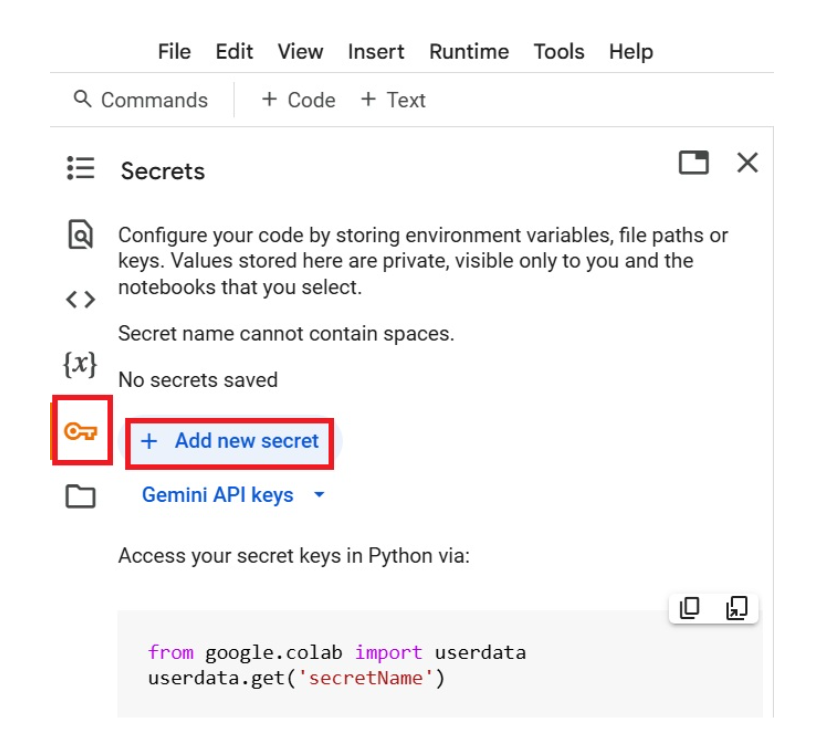

Add the two keys for **OPEN_API_KEY** and **OPEN_API_BASE**
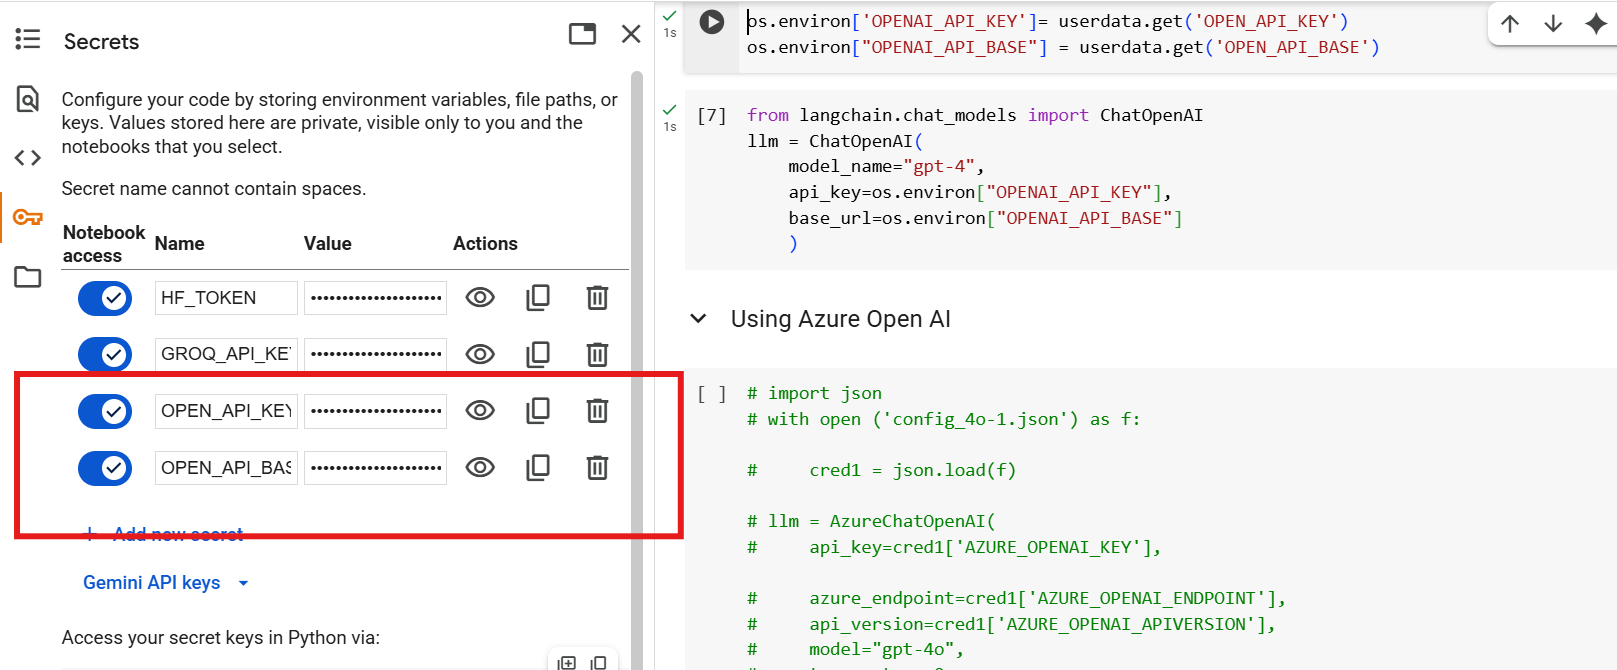

In [ ]:
os.environ['OPENAI_API_KEY']= userdata.get('OPEN_API_KEY')
os.environ["OPENAI_API_BASE"] = userdata.get('OPEN_API_BASE')

In [ ]:
from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(
    model_name="gpt-4",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_API_BASE"]
    )

# Introduction to Agents

The figure below presents the groundbreaking Rabbit R1, the world's premier action-oriented AI-powered device. It boasts the remarkable ability to execute user commands expressed in natural language, such as "Notify Chris of my delayed arrival for the meeting" with seamless efficiency. Central to its functionality lies an innovative operating system fueled by natural language processing, enabling it to orchestrate its hardware and software components to proactively *act* on tasks, rather than simply *react* to them.

In this module, we take a practical look at systems such as the R1 that use LLMs as reasoning agents to orchestrate a suite of tools to achieve specific objectives.

<center>
    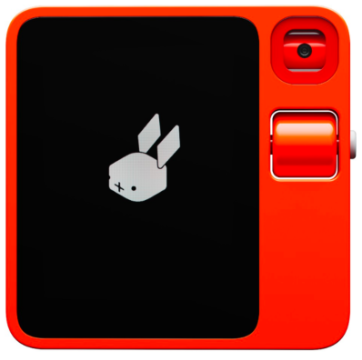
</center>

(Source: Rabbit R1 - https://www.rabbit.tech/)

As LLMs took the world by storm with their ability to execute natural language tasks (e.g., classification, summarization) with ease, early explorations of using LLMs as reasoning agents met with mixed success. As the success of *action-oriented* applications such as the Rabbit R1 demonstrates, we are at the dawn of a new future of LLM applications. A future where the reasoning abilities of LLMs can power *agents* that reason and *act* according to user instructions.

# Business Context

InventoX is a rapidly growing e-commerce company specializing in providing logistics and supply chain solutions for both B2B and B2C markets. With thousands of transactions processed daily and a vast network of suppliers, vendors, and warehouses, the company faces growing operational complexity. Making real-time decisions, optimizing workflows, and keeping track of financial markets are vital for the company’s continued success. However, manual intervention in these tasks often slows down decision-making processes.

To address these challenges, InventoX is exploring the potential of AI-driven agents capable of performing real-time actions, solving problems, and making decisions autonomously. Leveraging LangChain’s ReAct framework, these agents can interact with data sources, perform calculations, and extract valuable insights—allowing InventoX to optimize operations, stay updated on financial markets, and gain key business intelligence for better decision-making.


<center>
    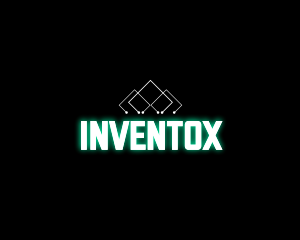
</center>


## What are Agents?

Agents are AI systems that:
1. Transform user objectives into a series of actionable steps.
2. Employ a curated array of tools tailored to the specific task at hand.
3. Methodically execute the outlined steps utilizing these specialized tools to effectively resolve user problems.

The figure below depicts a concrete instance of a software agent empowered by LLMs and furnishes users with database-driven responses tailored to their inquiries.

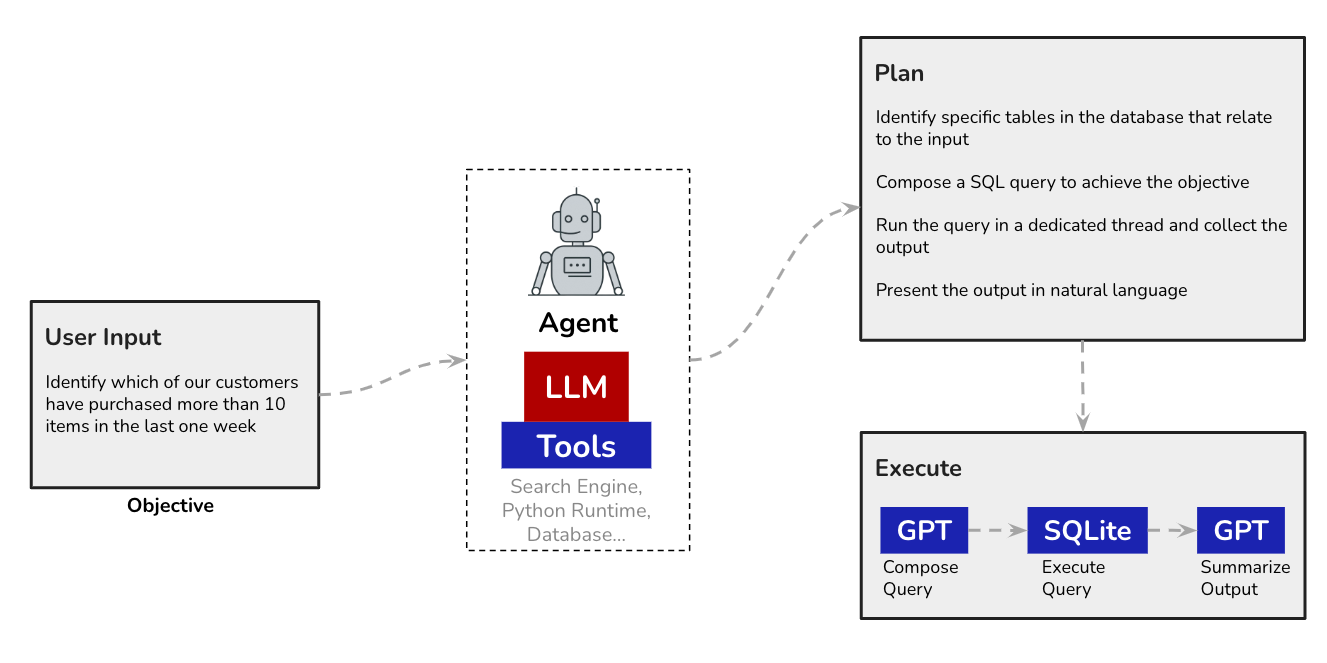

(Robot Image Source: Google Gemini)

In sum, agents use LLMs as reasoning agents to prescribe possible paths of action, then use appropriate tools to pursue these paths of action till the correct solution is found.

## The ReAct Approach

In the previous section, we established a general framework for agents. One specific paradigm that formalizes the planning and action process is the Reasoning and Action (ReAct) approach. With ReAct, an agent explicitly prompts a LLM for a specific course of action, generating a reasoning trace (referred to as a *thought*). The key idea of ReAct, however, is to constrain the action space of the agent to a pre-configured set of actions (for e.g., web search, calculators). This pre-configured set of actions is called the action space.

Each *thought* is a specific instance of options in the action space. Each action produces an *observation* and the LLM is prompted to think if the original objective is fulfilled by this observation. If the original objective is unfulfilled, this triggers another thought-action-observation step, and the process continues till the objective is achieved.

In sum, the ReAct approach allows the LLM to "think out aloud" pouring through the options available to it at any point. The LLM acts on its thoughts and observes the outcome. If the outcome is in line with the objective the chain-of-thought concludes and the agent reports the final solution.

The ReAct approach is summarized in the figure below.

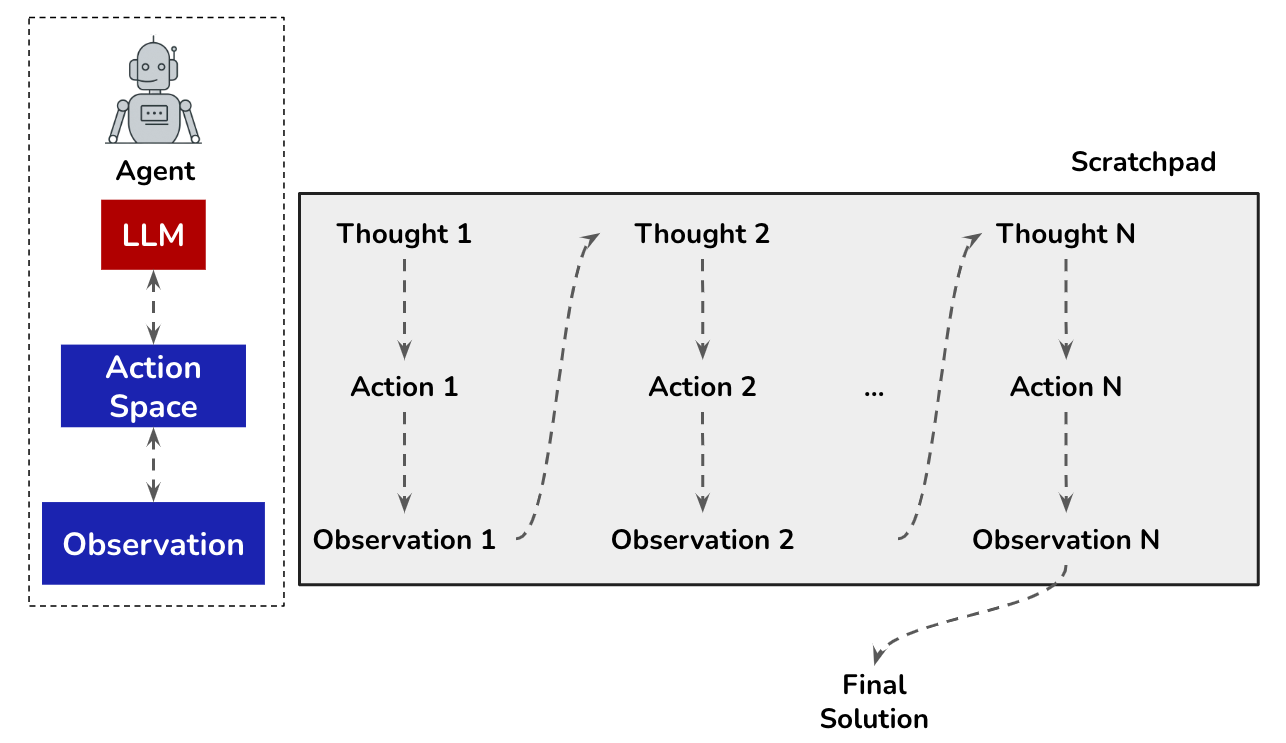

## `LangChain` implements ReAct

### Overview

One popular implementation of the ReAct framework is in the `langchain` package that offers several abstractions for different parts of the ReAct paradigm. LangChain also provides out-of-the box solutions to common problems solved by LLM Agents (e.g., Retrieval-Augmented Generation).

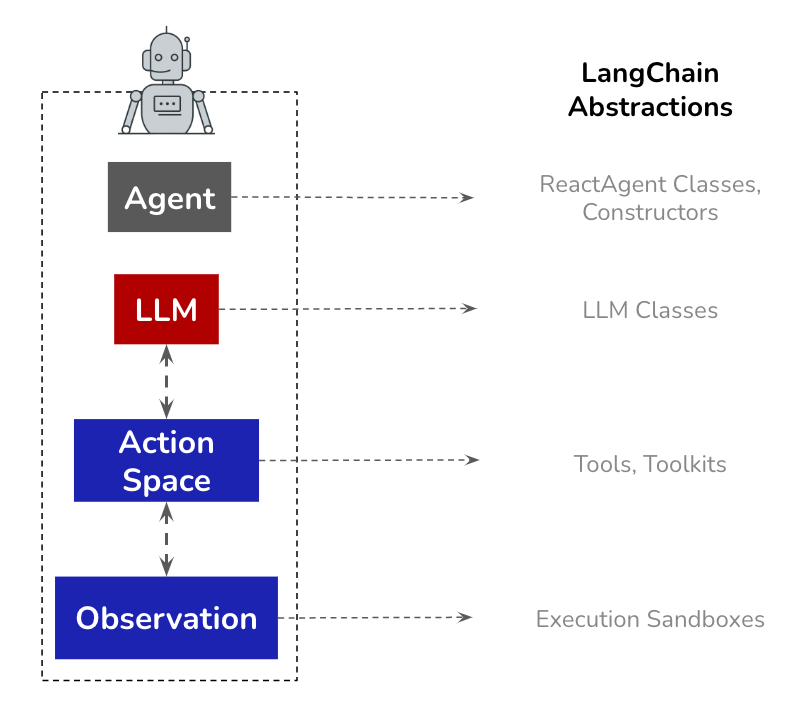

### Tools

An important abstraction that allows `langchain` agents to *act* are `Tool` classes. Each tool allows the agent to execute a specific action as a chain. Let us look at two such tools - `PythonREPL` & `DuckDuckGoSearchRun`.   

In [ ]:
python_repl = PythonREPL()

In [ ]:
python_repl.run("print('Hello World! I am a langchain tool that allows running arbitrary Python code')")

'Hello World! I am a langchain tool that allows running arbitrary Python code\n'

In [ ]:
python_repl.schema()

{'title': 'PythonREPL',
 'description': 'Simulates a standalone Python REPL.',
 'type': 'object',
 'properties': {'_globals': {'title': ' Globals', 'type': 'object'},
  '_locals': {'title': ' Locals', 'type': 'object'}}}

We can wrap this REPL as a tool that can be used by an agent like so:

In [ ]:
repl_tool = Tool(
    name="python_repl",
    description="A Python shell used to execute python commands. Input should be a valid python command.",
    func=python_repl.run,
)

We can now invoke this tool (just as an agent would do).

In [ ]:
repl_tool.invoke('print("Hello World!")')

'Hello World!\n'

In [ ]:
duckduckgo_search = DuckDuckGoSearchRun()

In [ ]:
duckduckgo_search.invoke("Who is the founder of Tesla?")

"Holiday Closings New Year's Day Monday, January 1 Martin Luther King Jr. Day Monday, January 20 President's Day Monday, February 17 Good Friday Friday, April 18 Memorial Day Monday, … Founders has competitive loan and deposit rates. Click below to view product rates! Founders offers many Mortgage Loan options to fit your lifestyle and your budget! Plus, Founders never charges PMI (Private Mortgage Insurance). Apply for Your Mortgage Find a Mortgage … Additional Features No minimum balance – keep as little or as much in your Checking Account as you need. No monthly fees – sign up for free eStatements 1 to have a Checking Account with … Aug 18, 2025 · You must be 18 years or older to qualify for a loan. Qualifications for a loan are based on the Credit Union’s criteria, including applicant’s income and credit history. *Must …"

In [ ]:
search_tool = Tool(
    name="duckduckgo_search",
    description="An interface to the DuckDuckGo search engine. Input should be a string.",
    func=duckduckgo_search.run,
)

We can now invoke the search tool (like an agent would do).

In [ ]:
search_tool.invoke("Who is the founder of Tesla?")

"Holiday Closings New Year's Day Monday, January 1 Martin Luther King Jr. Day Monday, January 20 President's Day Monday, February 17 Good Friday Friday, April 18 Memorial Day Monday, May 26 … Founders has competitive loan and deposit rates. Click below to view product rates! Founders offers many Mortgage Loan options to fit your lifestyle and your budget! Plus, Founders never charges PMI (Private Mortgage Insurance). Apply for Your Mortgage Find a Mortgage Loan … Additional Features No minimum balance – keep as little or as much in your Checking Account as you need. No monthly fees – sign up for free eStatements 1 to have a Checking Account with no … Aug 18, 2025 · You must be 18 years or older to qualify for a loan. Qualifications for a loan are based on the Credit Union’s criteria, including applicant’s income and credit history. *Must …"

With this overall framework in place, let us now create a few agents and see how the `langchain` abstractions work in practise.

# Example 1: Math Agent

## Math Agent: Automating Financial Projections for Supplier Contracts

**Scenario:** Inventory managers at InventoX frequently need to evaluate supplier credit terms, plan cash flows, and project future financial outcomes based on complex interest calculations. This is crucial for making informed decisions on when to place orders and how to optimize working capital. However, performing these calculations manually can be time-consuming and error-prone, especially when they involve different time horizons and interest rates.

**Objective:** The Math Agent is designed to handle complex financial and mathematical problems autonomously. Powered by the PythonREPL tool in LangChain, this agent can calculate compound interest, project future values, and perform other financial operations based on simple inputs. For example, if a manager needs to know how much a specific amount will accrue over time, the agent provides the answer instantly.


## Real-World Impact:

- **Improved Financial Planning:** The Math Agent allows managers to quickly calculate financial projections, such as interest accruals on loans or supplier credits. This automation speeds up the decision-making process, enabling managers to adjust supplier contracts or renegotiate payment terms.

- **Reduced Human Error:** By automating these calculations, the risk of human error in financial planning is minimized, which is especially important when dealing with large sums of money or critical business decisions.

- **Faster Cash Flow Optimization:** With real-time financial projections, InventoX can better plan its cash flow and optimize how it manages working capital, ensuring that the company remains financially healthy.

Let us now create an agent that is able to think through business math problems using the `PythonREPL` tool that we explored in the previous section.

In the following outputs notice how the ReAct `thought-action-observation` sequence is executed by the Math Agent we create using the abstractions of `langchain`.

Since the ReAct agent is a common abstraction, we can use a prompt that is hosted on the `langchain` hub.

In [ ]:
react_prompt = hub.pull("hwchase17/react")

Let us take a look at the prompt template that we just accesed.

In [ ]:
print(react_prompt.template)

In [ ]:
react_agent = create_react_agent(
    llm=llm,
    tools=[repl_tool],
    prompt=react_prompt
)

In [ ]:
react_agent.get_prompts()

[PromptTemplate(input_variables=['agent_scratchpad', 'input'], partial_variables={'tools': 'python_repl(command: str, timeout: Optional[int] = None) -> str - A Python shell used to execute python commands. Input should be a valid python command.', 'tool_names': 'python_repl'}, metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'}, template='Answer the following questions as best you can. You have access to the following tools:\n\n{tools}\n\nUse the following format:\n\nQuestion: the input question you must answer\nThought: you should always think about what to do\nAction: the action to take, should be one of [{tool_names}]\nAction Input: the input to the action\nObservation: the result of the action\n... (this Thought/Action/Action Input/Observation can repeat N times)\nThought: I now know the final answer\nFinal Answer: the final answer to the original input question\n\nBegin!\n\nQuestio

The agent now needs an executor to parse input and use the ReAct paradigm to plan and execute the objective mentioned in the input. Agent executors were introduced in `langchain` to separate the planning stage and the execution stage of the ReAct paradigm.

In [ ]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[repl_tool],
    verbose=True
)

In [ ]:
user_input = "If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?"

In [ ]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

{'input': 'If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?',
 'output': 'The amount will be approximately $ 500 in 2 years at the same interest rate.'}

# Example 2: Search Agent

## Search Agent: Tracking Financial Market Trends for Supply Chain Optimization

**Scenario:** InventoX relies heavily on external financial markets to make strategic supply chain decisions. For example, global stock market fluctuations can impact supplier pricing, shipping costs, and even product availability. The company needs to stay informed about these financial trends in real time to make informed adjustments to its supply chain operations.

**Objective:** The Search Agent uses tools like DuckDuckGoSearch and YahooFinanceNews to pull real-time data from financial markets. By asking simple questions, managers can access the latest stock prices, market trends, and significant news that affect their decision-making. This is particularly useful in volatile markets, where quick reactions to financial news can be the difference between profit and loss.


## Real-World Impact:

- **Proactive Risk Management:** The Search Agent helps InventoX keep an eye on external financial factors that may affect supplier pricing or shipping costs, enabling quick adjustments to contracts and operational decisions.

- **Data-Driven Decision Making:** With access to real-time financial market data, the company can anticipate and mitigate risks such as rising raw material prices, supplier disruptions, or currency fluctuations.

- **Competitive Advantage:** By staying informed about market trends, InventoX can react faster than competitors, ensuring more favorable terms with suppliers or taking advantage of price dips in raw materials.

Let us now create a finance news agent that empowers analysts to search for relevant financial information.

We will attach two tools to the agent - `DuckDuckGoSearch` & `YahooFinanceNewsTool`.

In [ ]:
duckduckgo_search = DuckDuckGoSearchRun()

In [ ]:
search_tool = Tool(
    name="duckduckgo_search",
    description="An interface to the DuckDuckGo search engine. Input should be a string.",
    func=duckduckgo_search.run,
)

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

def get_stock_price(ticker: str) -> str:
    """Fetch the latest stock price for a given ticker symbol."""
    try:
        stock = yf.Ticker(ticker)
        price = stock.history(period="1d")["Close"].iloc[-1]
        return f"The latest stock price of {ticker.upper()} is ${price:.2f}"
    except Exception as e:
        return f"Error fetching stock data: {str(e)}"

In [ ]:
yahoo_finance_tool = Tool(
    name="Yahoo Finance Stock Price",
    func=get_stock_price,
    description="Fetch the latest stock price of a given stock ticker (e.g., AAPL, TSLA, MSFT)."
)

In [ ]:
react_agent = create_react_agent(
    llm=llm,
    tools=[search_tool, yahoo_finance_tool],
    prompt=react_prompt
)

In [ ]:
react_agent.get_prompts()

[PromptTemplate(input_variables=['agent_scratchpad', 'input'], partial_variables={'tools': "duckduckgo_search(tool_input: 'Union[str, Dict[str, Any]]', verbose: 'Optional[bool]' = None, start_color: 'Optional[str]' = 'green', color: 'Optional[str]' = 'green', callbacks: 'Callbacks' = None, *, tags: 'Optional[List[str]]' = None, metadata: 'Optional[Dict[str, Any]]' = None, run_name: 'Optional[str]' = None, run_id: 'Optional[uuid.UUID]' = None, config: 'Optional[RunnableConfig]' = None, tool_call_id: 'Optional[str]' = None, **kwargs: 'Any') -> 'Any' - An interface to the DuckDuckGo search engine. Input should be a string.\nYahoo Finance Stock Price(ticker: str) -> str - Fetch the latest stock price of a given stock ticker (e.g., AAPL, TSLA, MSFT).", 'tool_names': 'duckduckgo_search, Yahoo Finance Stock Price'}, metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'}, template='Answer the foll

In [ ]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[search_tool, yahoo_finance_tool],
    verbose=True
)

In [ ]:
user_input = "What is the latest stock price of AAPL?"

In [ ]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

{'input': 'What is the latest stock price of AAPL?',
 'output': 'The latest stock price of AAPL is $227.16.'}

In [ ]:
user_input = "What was TSLA's quarterly revenue from the latest earnings call?"

In [ ]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

{'input': "What was TSLA's quarterly revenue from the latest earnings call?",
 'output': "I'm sorry, I was unable to find the specific information on Tesla's Q4 2021 revenue."}

In [ ]:
user_input = "Summarize three key reasons for the steep fall in the Indian stock market on 28th February 2024."

In [ ]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

{'input': 'Summarize three key reasons for the steep fall in the Indian stock market on 28th February 2024.',
 'output': "I'm sorry, but I couldn't find information about the Indian stock market on 28th February 2024. This might be because the date is in the future and specific information about events on this date is not available yet."}

In [ ]:
user_input=" What was the stock price variation of Netflix  in the last 3 months"

In [ ]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

{'input': ' What was the stock price variation of Netflix  in the last 3 months',
 'output': "I'm sorry, but I was not able to find the historical stock price variation for Netflix in the last 3 months with the tools available to me. You may be able to find this information on financial news websites or platforms that provide stock market data."}

# Example 3: SQL Agent

## SQL Agent: Automating User Engagement Insights for Marketing Campaigns

**Scenario:** InventoX operates multiple online platforms where customers interact with product listings and social media content. Understanding user behavior—such as what types of media users like, which regions have higher engagement rates, and identifying top influencers—can significantly improve marketing strategies and customer engagement. However, querying large databases to extract these insights manually takes time and effort.

**Objective:** The SQL Agent automates the process of querying databases for user behavior insights. Integrated with InventoX’s social media database, this agent can respond to natural language questions about user preferences, engagement levels, and regional patterns. By automating these queries, marketing teams can quickly extract insights and adapt their strategies in real time.

## Real-World Impact:

- **Personalized Marketing Campaigns:** With real-time insights into customer behavior, InventoX’s marketing team can tailor campaigns to specific regions, customer segments, or even individual users, increasing conversion rates and customer satisfaction.

- **Faster Customer Insights:** The SQL Agent reduces the time needed to analyze large datasets, providing immediate answers to questions about user behavior. This enables more agile marketing strategies.

- **Optimized Customer Engagement:** By understanding which users are most engaged, InventoX can target high-value customers with personalized offers or loyalty programs, improving overall engagement and retention.

Let us now create a database agent that translates user queries into valid SQL and executes this against the database. In contrast to the previous exampe, this agent is cutoff from the external world. It is rooted to the database on which it can run queries.

In [ ]:
connection = sqlite3.connect("socialmedia.db")

In [ ]:
path="/content/drive/MyDrive/GenAI/LLM Science and Engineering/"


In [ ]:
users_df = pd.read_csv("/content/likes.csv")
media_df = pd.read_csv("/content/media.csv")
likes_df = pd.read_csv("/content/likes.csv")

In [ ]:
users_df.sample(3)

,user_id,media_id,like_timestamp
4527,2280740784,foyqfldnzb,2022-09-04 17:03:54.002102400
3781,1028641696,rraiuofyna,2022-09-07 07:33:15.593616000
1049,3860770246,viszmshstf,2022-09-28 18:00:48.388838400


In [ ]:
likes_df.sample(3)

,user_id,media_id,like_timestamp
2416,2871722621,vjaveynopq,2022-09-13 22:56:46.058236800
4626,3878280413,shhkqcabys,2022-09-19 00:04:43.400380800
3657,3041444196,zijizspicy,2022-09-12 14:22:57.524505600


In [ ]:
users_df.to_sql('users', connection, if_exists='append', index=False)

4997

In [ ]:
media_df.to_sql('media', connection, if_exists='append', index=False)

500

In [ ]:
likes_df.to_sql('likes', connection, if_exists='append', index=False)

4997

In [ ]:
socialmedia_db = SQLDatabase.from_uri("sqlite:///socialmedia.db")

In [ ]:
sqlite_agent = create_sql_agent(
    llm,
    db=socialmedia_db,
    agent_type="openai-tools",
    verbose=True
)

Since this is a focused agent (i.e., executed only SQL), we do not need an executor to invoke this agent.

In [ ]:
sqlite_agent.invoke("How many users have the location as DEL?")

{'input': 'How many users have the location as DEL?',
 'output': "It seems there is no 'location' field in the 'users' table. Therefore, we cannot answer this question with the available data."}

Let us check if the answer is correct.

In [ ]:
sqlite_agent.invoke("How many users have liked more than 3 media items?")

{'input': 'How many users have liked more than 3 media items?',
 'output': 'There are 24 users who have liked more than 3 media items.'}

In [ ]:
sqlite_agent.invoke(
    "What is the location of the user who has liked most media items?"
    " Who is this user and how many media did this user like?"
)

{'input': 'What is the location of the user who has liked most media items? Who is this user and how many media did this user like?',
 'output': "It appears there's been a mistake in displaying the schema for the 'users' table. It's showing the same columns as the 'likes' table which doesn't make sense. I'll need to query the schema for the 'users' table again."}

# Conclusion

This hands-on notebook provided a practical deep dive into the capabilities of AI-driven agents using the LangChain framework, demonstrating how agents can automate complex tasks across a variety of domains. Through this notebook, you explored several types of agents—Math, Search, and SQL—and learned how to build and integrate them into workflows to solve real-world business problems.

**Key takeaways from this notebook:**

- **Seamless Task Automation:** The Math Agent highlighted the power of automating repetitive yet critical calculations, such as financial projections. This shows how AI can enhance productivity by handling tasks that would otherwise be time-consuming and prone to human error.

- **Real-Time Information Retrieval:** The Search Agent demonstrated how AI can tap into real-time data from external sources, such as financial markets. By automating data collection, agents can help users make informed decisions based on the most up-to-date information, improving accuracy and responsiveness in dynamic environments.

- **Intelligent Database Querying:** The SQL Agent illustrated the utility of natural language interfaces for database interactions. This simplifies querying large datasets, providing immediate insights and helping businesses make data-driven decisions without the need for complex SQL knowledge.

## Broader Applications and Impact

Through the lens of this hands-on experience, it's clear that AI-driven agents are transformative tools for automating decision-making processes across various industries. The notebook not only enhanced your technical skills in building and deploying agents but also provided insight into the real-world applications of these technologies. Whether in finance, marketing, or customer service, agents help solve problems faster, extract actionable insights, and optimize operations.

By mastering these concepts, you are better equipped to apply AI agents to real-world challenges, scaling their use in any domain where efficiency, automation, and intelligent decision-making are key objectives. The ability to integrate AI agents into workflows positions you to drive innovation and automation in future projects, furthering the development of autonomous, data-driven solutions across industries.